# AI: Machine Learning Foundation
## Data Preparation | Individual Assignment I

Student's Name: Madhushri D/O Vijayakumar 

Submission Deadline: 4 Mar 2026, 11:59

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, confusion_matrix,
                              classification_report)

from imblearn.over_sampling import SMOTE

## Task 1: Identifying the Prediction Target

The target is `y`, a binary column (`"yes"` / `"no"`) indicating whether a client subscribed to a term deposit. It is the direct outcome of the campaign and is only known after the call, making it a valid prediction target. Logistic Regression models this as $P(y = 1 \mid \mathbf{x})$.

Two columns are not valid targets:

- `duration`: last call length in seconds. It is recorded during the call, so it is unavailable before prediction time and leaks information about the outcome.
- `poutcome`: result of a previous campaign. This is historical input data, not the current outcome we are trying to predict.

In [2]:
# load data
df = pd.read_csv("bank-additional-full.csv", sep=";")

TARGET = "y"
NON_TARGETS = ["duration", "poutcome"]

# check target dist
print(df[TARGET].value_counts())

# confirm non-target dtypes
for col in NON_TARGETS:
    print(f"{col}: dtype={df[col].dtype}, nunique={df[col].nunique()}")

y
no     36548
yes     4640
Name: count, dtype: int64
duration: dtype=int64, nunique=1544
poutcome: dtype=object, nunique=3


## Task 2: Task Ordering

The pipeline is ordered so that each step only uses information it is allowed to have at that point. The central rule is: split before fitting any transformation, then fit every transformation on training data only.

- **Task 1 (Identifying the Prediction Target).** Allowed: full raw dataset for column inspection. Restricted: none. If skipped, all downstream decisions (encoding strategy, loss function, feature relevance) would be made without a defined objective, making the pipeline arbitrary.

- **Task 2 (Task Ordering).** Allowed: knowledge of the dataset structure and algorithm requirements. Restricted: no data has been loaded yet. If ordering is not planned upfront, random decisions during later steps can silently introduce leakage that is hard to trace back.

- **Task 3 (Data Loading and Exploration).** Allowed: the full raw dataset for descriptive statistics only. Restricted: no fitted parameters (means, encodings, scales) may be derived here for reuse. If exploration statistics were directly reused as transformation parameters, they would incorporate test-set values, leaking distributional information into the pipeline.

- **Task 4 (Data Splitting).** Allowed: the full raw dataset. Restricted: no transformation of any kind before this point. If any fitting step (imputation, encoding, scaling) precedes the split, the fitted parameters reflect the entire dataset including the test set, making the test set no longer a trustable proxy for unseen data.

- **Task 5 (Managing Missing Values).** Allowed: imputation parameters fitted on training data only. Restricted: test and validation set values must not influence the fill value. If imputation is done before splitting, the fill statistic absorbs test-set distributions. If done after encoding, implicit missing values in categorical columns will already be encoded incorrectly.

- **Task 6 (Encoding Categorical Variables).** Allowed: category mappings learned from the training set only. Restricted: test-set category frequencies must not inform the encoder. If encoding is done before splitting, frequency-based or ordinal encoders learn from the full distribution, leaking test-set label structure into the training process.

- **Task 7 (Feature Scaling).** Allowed: mean $\mu$ and standard deviation $\sigma$ computed from training data only, applied as $z = (x - \mu_\text{train}) / \sigma_\text{train}$ to all sets. Restricted: validation and test set statistics must not be used to define the scale. If scaling is done before splitting, the scaler's $\mu$ and $\sigma$ reflect the full dataset, making the test set appear closer to the training distribution than it actually is.

- **Task 8 (Feature Selection).** Allowed: feature-target correlations and variance computed on training data only. Restricted: test-set labels must not influence which features survive. If selection is done on the full dataset, features are chosen partly because of their relationship with test-set labels, which is a form of target leakage.

- **Task 9 (Addressing Class Imbalance).** Allowed: resampling applied only to the training set, after all transformations are fitted. Restricted: synthetic samples must never enter the validation or test set. If SMOTE is applied before splitting, synthetic records generated from training examples appear in the test set, inflating evaluation metrics in a way that does not reflect real deployment performance.

- **Task 10 (Training a Logistic Regression Model).** Allowed: the fully preprocessed training set for fitting; the validation set for hyperparameter tuning; the test set once for final evaluation. Restricted: the test set must not be used during training or tuning. Using test labels to guide any earlier decision converts the test set effectively into training set, invalidating the final reported metrics.

## Task 3: Data Loading and Exploration

Loading the dataset and inspecting its structure gives a full picture of the raw data before any transformation is applied. This step is purely descriptive. No statistics computed here are reused as transformation parameters.

Detecting `"unknown"` entries matters because they are implicit missing values encoded as a valid category string. Standard null-detection methods like `isnull()` will miss them entirely, so they must be counted separately before deciding on an imputation strategy.

One variable requiring special consideration is `duration`. It records last call length in seconds and is strongly correlated with `y`, but it is only known after the call ends. It must be dropped before modeling to prevent data leakage.

shape: (41188, 21)

dtypes:
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

summary stats:
               age      duration      campaign         pdays      previous  \
count  41188.00000  41188.000000  41188.000000  41188.000000  41188.000000   
mean      40.02406    258.285010      2.567593    962.475454      0.172963   
std       10.42125    259.279249      2.770014    186.910907      0.494901   
min       17.00000      0.000000      1.000000      0.000000      0.000000   
25%   

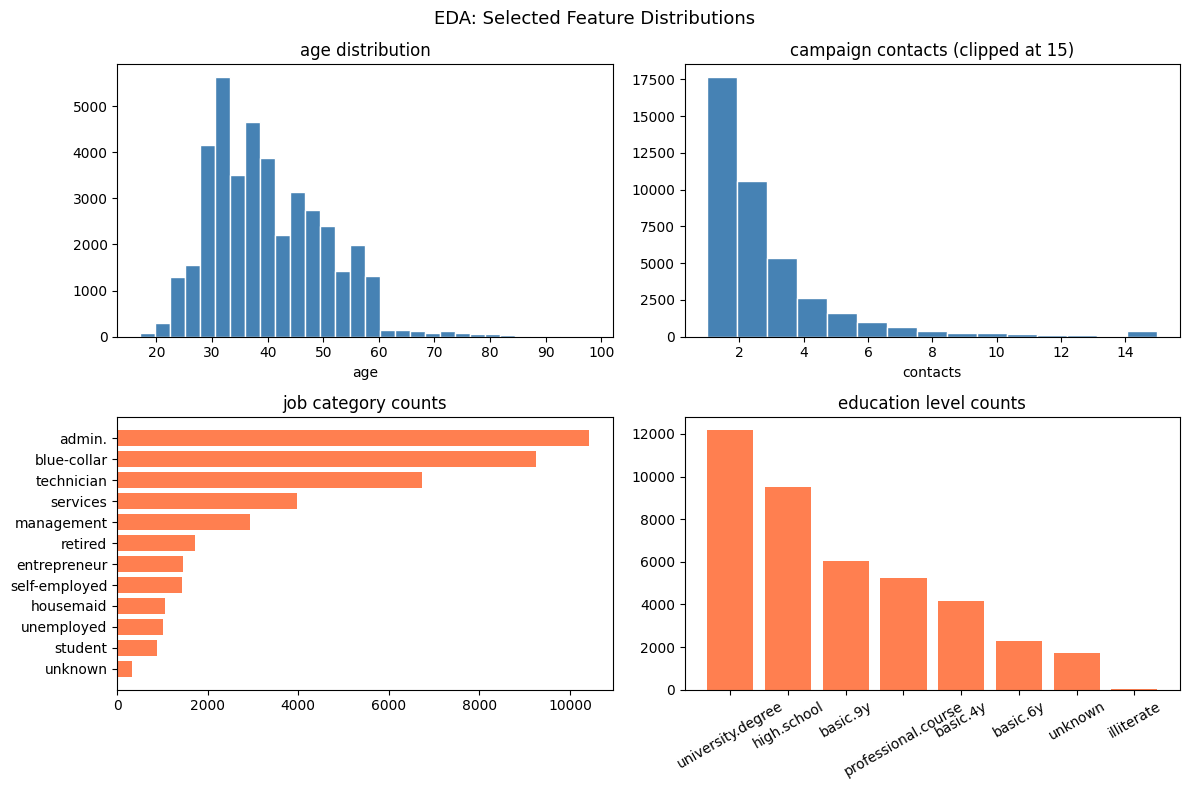

In [3]:
# load data
df = pd.read_csv("bank-additional-full.csv", sep=";")

# basic structure
print(f"shape: {df.shape}")
print(f"\ndtypes:\n{df.dtypes}")
print(f"\nsummary stats:\n{df.describe()}")

# split cols by type
num_cols = df.select_dtypes(include="number").columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()
print(f"\nnumerical ({len(num_cols)}): {num_cols}")
print(f"categorical ({len(cat_cols)}): {cat_cols}")

# target dist
print(f"\ntarget dist:\n{df['y'].value_counts()}")
print(f"imbalance ratio: {df['y'].value_counts(normalize=True).round(3).to_dict()}")

# explicit nulls
print(f"\nnull counts:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

# implicit nulls ("unknown")
unknown_counts = (df == "unknown").sum()
print(f"\n'unknown' counts:\n{unknown_counts[unknown_counts > 0]}")

# plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("EDA: Selected Feature Distributions", fontsize=13)

# numerical: age
axes[0, 0].hist(df["age"], bins=30, color="steelblue", edgecolor="white")
axes[0, 0].set_title("age distribution")
axes[0, 0].set_xlabel("age")

# numerical: campaign (no. contacts this campaign)
axes[0, 1].hist(df["campaign"].clip(upper=15), bins=15, color="steelblue", edgecolor="white")
axes[0, 1].set_title("campaign contacts (clipped at 15)")
axes[0, 1].set_xlabel("contacts")

# categorical: job
job_counts = df["job"].value_counts()
axes[1, 0].barh(job_counts.index, job_counts.values, color="coral")
axes[1, 0].set_title("job category counts")
axes[1, 0].invert_yaxis()

# categorical: education
edu_counts = df["education"].value_counts()
axes[1, 1].bar(edu_counts.index, edu_counts.values, color="coral")
axes[1, 1].set_title("education level counts")
axes[1, 1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### EDA Summary

The dataset has 41,188 observations and 21 columns in total, of which 20 are input features and one (`y`) is the target.

**Numerical features (10):** `age`, `duration`, `campaign`, `pdays`, `previous`, `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`. These are continuous or discrete count variables that capture client demographics, campaign contact history, and macroeconomic context.

**Categorical features (10, excluding target):** `job`, `marital`, `education`, `default`, `housing`, `loan`, `contact`, `month`, `day_of_week`, `poutcome`. These are nominal or ordinal string variables that will require encoding before modeling.

There are no explicit null values. `isnull()`, blank string checks, and whitespace checks all return zero across every column. However, there are two forms of masked missing data. First, several categorical columns encode missing information as the string `"unknown"`: `default` (8,597 entries), `education` (1,731), `job` (330), `marital` (80), `housing` (990), and `loan` (990). These will not be caught by standard null detection and must be handled explicitly during imputation. Second, `pdays` uses the sentinel value `999` to indicate that a client was not contacted in a previous campaign. This is a numerical column where `999` carries a categorical meaning ("no prior contact") and is not a real measurement. It will need special treatment before or during feature engineering.

The target distribution is heavily skewed: approximately 89% of records are `"no"` and 11% are `"yes"`. A model that always predicts the majority class would achieve 89% accuracy without learning anything useful, so a resampling strategy is needed in Task 9.

The `age` distribution is right-skewed with most clients between 25 and 55. The `campaign` variable is similarly skewed, with most clients contacted once or twice and a long tail of high-contact outliers. This kind of scale disparity across numerical features supports the case for standardisation in Task 7, since Logistic Regression's gradient updates are sensitive to feature magnitude.

Among categorical features, `job` and `education` show uneven class frequencies alongside `"unknown"` entries. Heavily skewed categories increase the chance of rare or unseen levels appearing in the test set, which motivates one-hot encoding over ordinal encoding in Task 6.

The variable `duration` must be dropped before modeling. Its strong correlation with `y` is post-hoc: call length is only recorded after the call ends, so it is unavailable at prediction time. Including it constitutes data leakage.

## Task 4: Data Splitting

The dataset is split into three partitions: training (70%), validation (15%), and test (15%). The training set is used to fit all transformations and the model. The validation set is used to tune hyperparameters and evaluate interim decisions without touching the test set. The test set is reserved for a single final evaluation, simulating how the model would perform on genuinely unseen data. A 70/15/15 split is appropriate here because the dataset is large enough (41,188 rows) that 15% partitions still yield roughly 6,000 samples each, which is sufficient for stable evaluation.

The split is stratified on `y`. With an 89/11 class imbalance, a random split has a non-trivial chance of producing partitions where the minority class is over- or under-represented relative to the full dataset. Stratification enforces that each partition preserves the original class proportions, ensuring that no split is inadvertently harder or easier to predict than another.

The split must occur before any transformation is fitted. Every step from Task 5 onward learns parameters from data. If any of those steps precede the split, the parameters will reflect the full dataset including rows that will later become the validation or test set. This is data leakage. That means to say:

- An imputer fitted before splitting computes fill values using test-set rows, so the test set is no longer independent.
- A scaler fitted before splitting absorbs the test set's mean and variance, making the test set appear distributed like the training data when it may not be in production.
- SMOTE applied before splitting generates synthetic minority samples from the full dataset; some of those synthetic points end up in the test set, inflating evaluation metrics.

`duration` is dropped here, before any split, since it is a pre-split structural decision based on domain knowledge established in Task 1, not a learned transformation.

In [4]:
# drop leaky col before any split
df_clean = df.drop(columns=["duration"])

# separate features and target
X = df_clean.drop(columns=["y"])
y = df_clean["y"]

# first split: 70% train, 30% temp (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# second split: temp -> 50% val, 50% test (each = 15% of total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# confirm shapes
print(f"train : {X_train.shape}, {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"val   : {X_val.shape},   {y_val.value_counts(normalize=True).round(3).to_dict()}")
print(f"test  : {X_test.shape},  {y_test.value_counts(normalize=True).round(3).to_dict()}")

train : (28831, 19), {'no': 0.887, 'yes': 0.113}
val   : (6178, 19),   {'no': 0.887, 'yes': 0.113}
test  : (6179, 19),  {'no': 0.887, 'yes': 0.113}


## Task 5: Managing Missing Values

### Explicit Missing Values

`isnull()` returns zero across all columns. There are no NaN entries in the raw dataset.

### Implicit Missing Values

Two types exist and require different treatment.

**Type 1: `"unknown"` strings in categorical columns.** Six columns use `"unknown"` as a placeholder for undisclosed or unrecorded information. Counts from the training set:

- `default`: 6,051 (21.0%)
- `education`: 1,234 (4.3%)
- `housing`: 707 (2.5%)
- `loan`: 707 (2.5%)
- `job`: 240 (0.8%)
- `marital`: 58 (0.2%)

For `default`, the 21% rate is high enough that the missingness itself may carry predictive signal. A client who declines to disclose default status may behave differently from one who reports no default. This is a modeling decision: retain `"unknown"` as a distinct category level rather than imputing it away. No learned parameter is needed.

For the remaining five columns (`job`, `marital`, `education`, `housing`, `loan`), the proportions are small and missingness is unlikely to be systematically informative. This is a data cleaning decision: replace `"unknown"` with NaN and impute with the mode of the training set. The mode is a learned parameter and must be computed from the training set only. Applying a mode fitted on the full dataset would allow test-set category frequencies to influence the fill value.

**Type 2: `pdays = 999` sentinel.** `pdays` records days since a client was last contacted in a previous campaign. The value `999` is a sentinel code meaning "not previously contacted," not a real measurement. In the training set, 27,734 of 28,831 rows (96.2%) carry this value, leaving only 1,097 rows with genuine contact-day data.

I will need to act on two actions. First, a binary flag `pdays_contacted` is created (1 if `pdays != 999`, else 0). This is a data cleaning decision based on domain knowledge and uses no learned parameter. Second, the 999 sentinels are replaced with NaN and imputed using the median of non-999 training values (6 days). The median is a learned parameter and must be fitted on the training set only. Both the flag and the retained `pdays` column are passed to Task 8 (Feature Selection), which will determine whether the flag alone is sufficient or whether the raw contact-day value adds signal.

In [5]:
# cols where "unknown" will be imputed with mode (low missingness, non-informative)
MODE_IMPUTE_COLS = ["job", "marital", "education", "housing", "loan"]

# "default" keeps "unknown" as a category level - no action needed

# quantify missingness in training set
print("implicit missing: 'unknown' counts in X_train:")
unknown_train = (X_train == "unknown").sum()
print(unknown_train[unknown_train > 0])

print(f"\npdays sentinel (999) in X_train: {(X_train['pdays'] == 999).sum()} / {len(X_train)}")

# fit mode on training set only
mode_fill = {col: X_train[col].replace("unknown", np.nan).mode()[0] for col in MODE_IMPUTE_COLS}
print(f"\nmode fill values (from train): {mode_fill}")

# fit pdays median on non-sentinel training rows
pdays_median = X_train.loc[X_train["pdays"] != 999, "pdays"].median()
print(f"pdays median (non-999, from train): {pdays_median}")

# helper: apply all imputation to a split
def apply_imputation(X, mode_fill, pdays_median):
    X = X.copy()
    # replace "unknown" with mode for low-missingness cols
    for col, fill in mode_fill.items():
        X[col] = X[col].replace("unknown", fill)
    # pdays: add binary flag, then replace sentinel with median
    X["pdays_contacted"] = (X["pdays"] != 999).astype(int)
    X["pdays"] = X["pdays"].replace(999, np.nan).fillna(pdays_median)
    return X

# apply to all splits (fitted params from train only)
X_train = apply_imputation(X_train, mode_fill, pdays_median)
X_val   = apply_imputation(X_val,   mode_fill, pdays_median)
X_test  = apply_imputation(X_test,  mode_fill, pdays_median)

# verify no unknowns remain in mode-imputed cols
print("\n unknowns remaining after imputation:")
for col in MODE_IMPUTE_COLS:
    remaining = (X_train[col] == "unknown").sum()
    print(f"  {col}: {remaining}")

print(f"\nX_train shape after imputation: {X_train.shape}")
print(f"pdays_contacted value counts (train):\n{X_train['pdays_contacted'].value_counts()}")
print(f"\ndefault 'unknown' retained (train): {(X_train['default'] == 'unknown').sum()}")

implicit missing: 'unknown' counts in X_train:
job           240
marital        58
education    1234
default      6051
housing       707
loan          707
dtype: int64

pdays sentinel (999) in X_train: 27734 / 28831

mode fill values (from train): {'job': 'admin.', 'marital': 'married', 'education': 'university.degree', 'housing': 'yes', 'loan': 'no'}
pdays median (non-999, from train): 6.0

 unknowns remaining after imputation:
  job: 0
  marital: 0
  education: 0
  housing: 0
  loan: 0

X_train shape after imputation: (28831, 20)
pdays_contacted value counts (train):
pdays_contacted
0    27734
1     1097
Name: count, dtype: int64

default 'unknown' retained (train): 6051


## Task 6: Encoding Categorical Variables

After imputation, 10 categorical columns remain. Logistic Regression requires all inputs to be numeric. The encoding strategy is not purely mechanical. The choice between ordinal and one-hot encoding directly affects what the model's coefficients mean and how the decision boundary is shaped.

### Nominal vs Ordinal Classification

`education` is ordinal. Its levels have a progression in years of schooling: `illiterate < basic.4y < basic.6y < basic.9y < high.school < professional.course < university.degree`. Assigning integers 0 to 6 is justified because the gaps are approximately uniform and the ordering is substantive. Using ordinal encoding keeps this column as a single feature with a coefficient that Logistic Regression can interpret as "each additional education level changes the log-odds by a fixed amount." One-hot encoding would discard the ordering and add 6 columns unnecessarily.

All remaining nine categorical columns are nominal: `job`, `marital`, `default`, `housing`, `loan`, `contact`, `month`, `day_of_week`, `poutcome`. None have a natural ordering that carries meaningful magnitude. Imposing integers would create a false hierarchy. For example, encoding `job` as admin=0, blue-collar=1, technician=2 would imply blue-collar is "between" admin and technician, which has no interpretive meaning. One-hot encoding (OHE) avoids this by representing each level as an independent binary feature.

### Why Encoders Must Be Fitted on Training Data Only

OHE fitted on the full dataset would observe category frequencies and level sets from the test set. If the test set contains a category level absent from training, a training-fitted encoder will handle it consistently (by ignoring or erroring, depending on configuration), whereas a full-dataset encoder would silently encode test-set-only levels and inject that information into the training columns. The category-to-column mapping must reflect only what the model was trained on.

### Effect on Dimensionality, Coefficients, and Decision Boundary

OHE with `drop="first"` is used to avoid perfect multicollinearity (the dummy variable trap). Without dropping one level, the sum of all dummies for a column equals 1, making the feature matrix rank-deficient. A rank-deficient matrix has no unique least-squares solution, which destabilises Logistic Regression's coefficient estimates. Dropping one level (the reference category) removes the linear dependency.

The encoding expands the feature space from 20 columns to 43: the 10 categorical columns are replaced by 1 ordinal column (`education`) and 32 OHE columns, while the 10 numerical columns are unchanged. Each OHE binary feature gets its own coefficient in the model. The coefficient for, say, `job_student` represents the change in log-odds of subscription when `job = student` relative to the dropped reference level, holding all other features constant. This makes coefficients interpretable in the context of specific category contrasts.

Logistic Regression produces a linear decision boundary in the encoded feature space. OHE allows the model to learn a separate log-odds contribution for each category level independently, which is more expressive than a single integer-encoded coefficient that forces a linear relationship across all levels.

In [6]:
# ordinal col with explicit level order (low to high education)
ORDINAL_COL = "education"
EDUCATION_ORDER = [["illiterate", "basic.4y", "basic.6y", "basic.9y",
                     "high.school", "professional.course", "university.degree"]]

# nominal cols for OHE (all remaining object cols except ordinal)
OHE_COLS = ["job", "marital", "default", "housing", "loan",
            "contact", "month", "day_of_week", "poutcome"]

# fit ordinal encoder on train only
ord_enc = OrdinalEncoder(categories=EDUCATION_ORDER)
ord_enc.fit(X_train[[ORDINAL_COL]])

# fit OHE on train only, drop first level to avoid dummy trap
ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
ohe.fit(X_train[OHE_COLS])

def apply_encoding(X, ord_enc, ohe, ordinal_col, ohe_cols):
    X = X.copy()
    # ordinal encode education in-place
    X[ordinal_col] = ord_enc.transform(X[[ordinal_col]])
    # one-hot encode nominal cols, then concat and drop originals
    ohe_arr = ohe.transform(X[ohe_cols])
    ohe_df  = pd.DataFrame(ohe_arr, columns=ohe.get_feature_names_out(ohe_cols), index=X.index)
    X = X.drop(columns=ohe_cols)
    X = pd.concat([X, ohe_df], axis=1)
    return X

X_train = apply_encoding(X_train, ord_enc, ohe, ORDINAL_COL, OHE_COLS)
X_val   = apply_encoding(X_val,   ord_enc, ohe, ORDINAL_COL, OHE_COLS)
X_test  = apply_encoding(X_test,  ord_enc, ohe, ORDINAL_COL, OHE_COLS)

# confirm shape and dtypes
print(f"X_train shape after encoding: {X_train.shape}")
print(f"\neducation encoded sample (first 5):\n{X_train['education'].value_counts().sort_index()}")
print(f"\nOHE feature names ({len(ohe.get_feature_names_out(OHE_COLS))}):")
print(ohe.get_feature_names_out(OHE_COLS).tolist())
print(f"\nno object cols remaining: {X_train.select_dtypes(include='object').shape[1] == 0}")

X_train shape after encoding: (28831, 43)

education encoded sample (first 5):
education
0.0      12
1.0    2865
2.0    1615
3.0    4218
4.0    6690
5.0    3679
6.0    9752
Name: count, dtype: int64

OHE feature names (32):
['job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_married', 'marital_single', 'default_unknown', 'default_yes', 'housing_yes', 'loan_yes', 'contact_telephone', 'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed', 'poutcome_nonexistent', 'poutcome_success']

no object cols remaining: True


## Task 7: Feature Scaling

### Which Columns Need Scaling

After encoding, the dataset has 43 columns. The 32 OHE binary columns and the `pdays_contacted` flag are already in {0, 1} and do not need scaling. The 10 continuous and ordinal columns do:

`age` (17 to 98), `education` (0 to 6), `campaign` (1 to 56), `pdays` (0 to 27), `previous` (0 to 7), `emp.var.rate` (-3.4 to 1.4), `cons.price.idx` (92.2 to 94.8), `cons.conf.idx` (-50.8 to -26.9), `euribor3m` (0.6 to 5.0), `nr.employed` (4963.6 to 5228.1).

`nr.employed` ranges over 260 units while `emp.var.rate` ranges under 5. Without scaling, gradient updates are dominated by features with large absolute values which causes slower and/or uneven convergence.

### Why Standardisation, Not Normalisation

Standardisation (z-score scaling) is used:

$$z = \frac{x - \mu_{\text{train}}}{\sigma_{\text{train}}}$$

Min-max normalisation is sensitive to outliers because it maps the observed minimum and maximum to [0, 1]. `campaign` has a maximum of 56 but is heavily concentrated at 1 to 2 (as seen in EDA), so a handful of high-contact rows would compress the bulk of the distribution into a narrow band near zero. Standardisation is more robust because it centers on the mean and scales by spread (not by extremes).

### The Scaler Must Be Fitted on Training Data Only

`StandardScaler` computes $\mu$ and $\sigma$ from the data it is fitted on. If fitted on the full dataset, these statistics reflect the test set's distribution. The test set would then be scaled relative to its own distribution rather than the training distribution, making it appear more similar to the training data than it actually is. This inflates evaluation metrics. Fitting on the training set only and transforming all three splits using those parameters ensures the evaluation faithfully represents generalisation to unseen data.

### Effect on Gradient-Based Optimisation

Logistic Regression minimises:

$$\mathcal{L}(\mathbf{w}) = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log \hat{p}_i + (1 - y_i) \log(1 - \hat{p}_i) \right] + \frac{\lambda}{2} \|\mathbf{w}\|^2$$

Features with very different scales cause gradient‑based solvers to take uneven steps. Large‑range features dominate the updates, while small‑range features barely move the gradient. This makes the optimisation slow and unstable. Standardising the data puts all features on a similar scale, so the solver can move smoothly and converge more reliably.

### Effect on Magnitude and Comparability of Model Coefficients

After standardisation, each coefficient $w_j$ represents the change in log-odds of subscription for a one standard deviation increase in feature $x_j$, holding all other features constant. This makes coefficients directly comparable across features. A larger absolute coefficient means a one-SD shift in that feature produces a greater change in the predicted probability, regardless of the original unit or scale.

Without scaling, coefficients are not comparable. The coefficient for `nr.employed` would be tiny (because a one-unit change in a range of 5,000 is almost meaningless), while the coefficient for `emp.var.rate` would be large. Comparing their magnitudes would give a false impression that `emp.var.rate` is far more important, when the difference is just because of scale. After standardisation, ranking coefficients by absolute value is a valid indicator of relative feature influence.

### Effect on Regularisation

Based on documentation, Scikit-learn's Logistic Regression applies L2 regularisation uniformly across all coefficients. If features are on different scales, the penalty is applied unequally. That means to say, a raw coefficient for `nr.employed` is naturally very small, so L2 shrinks it very little. A raw coefficient for `emp.var.rate` is naturally large, so L2 shrinks it aggressively. The differential shrinkage is driven by scale, not by actual predictive importance. After standardisation, all coefficients occupy a comparable range and the regularisation penalty applies consistently across features.

In [7]:
# continuous/ordinal cols to scale (binary 0/1 cols excluded)
SCALE_COLS = ["age", "education", "campaign", "pdays", "previous",
              "emp.var.rate", "cons.price.idx", "cons.conf.idx",
              "euribor3m", "nr.employed"]

# fit scaler on training set only
scaler = StandardScaler()
scaler.fit(X_train[SCALE_COLS])

# apply same scaler to all splits
X_train[SCALE_COLS] = scaler.transform(X_train[SCALE_COLS])
X_val[SCALE_COLS]   = scaler.transform(X_val[SCALE_COLS])
X_test[SCALE_COLS]  = scaler.transform(X_test[SCALE_COLS])

# verify: train cols should have mean ~0 and std ~1
print("post-scaling stats (train only):")
stats = X_train[SCALE_COLS].agg(["mean", "std"]).round(4)
print(stats)

print(f"\nX_train shape unchanged: {X_train.shape}")
print(f"binary cols untouched (e.g. housing_yes mean): {X_train['housing_yes'].mean():.3f}")

post-scaling stats (train only):
      age  education  campaign  pdays  previous  emp.var.rate  cons.price.idx  \
mean -0.0       -0.0      -0.0   -0.0       0.0          -0.0             0.0   
std   1.0        1.0       1.0    1.0       1.0           1.0             1.0   

      cons.conf.idx  euribor3m  nr.employed  
mean            0.0        0.0          0.0  
std             1.0        1.0          1.0  

X_train shape unchanged: (28831, 43)
binary cols untouched (e.g. housing_yes mean): 0.549


## Task 8: Feature Selection

### Why Feature Selection on Training Set (and consequences if done before splitting)

Feature selection must be done using statistics computed from the training set only. Two specific consequences arise if either filter is computed on the full dataset instead.

**Variance filter on full data.** The variance of a feature across all 41,188 rows is not the same as its variance in the training set alone. A column like `default_yes` has near-zero variance in the training set, but if the test set happened to contain a slightly different proportion of the minority value, the full-dataset variance would be inflated. A column that should have been dropped based on training-set evidence might survive the filter because test-set rows pushed its variance above the threshold. This biases the evaluation as the test set has influenced the feature set, and the reported test-set metrics reflect a decision made partly using test-set structure.

**Correlation filter on full data.** Correlations computed on the full dataset mix training and test observations. The full-dataset correlation between `euribor3m` and `emp.var.rate` may differ from the training-set correlation if recent economic conditions are concentrated in the test rows. A feature pair that exceeds the correlation threshold in the training set might fall below it in the full-dataset calculation, causing both features to be retained when one should have been dropped. 

In both cases, the test set is no longer independent. It has shaped the feature set, so the final evaluation metrics are overly optimistic and hence, cannot be trusted as an honest estimate of general (real) performance.

### Low Variance Removal

A feature with near-zero variance carries almost no information because it takes nearly the same value across all rows, so it cannot shift the decision boundary. For Logistic Regression specifically, a near-constant feature produces a coefficient that is numerically unstable. The solver must fit a weight for a predictor that provides almost no gradient signal, and with L2 regularisation that coefficient will be shrunk toward zero anyway, contributing nothing.

The threshold is set at variance < 0.01 after scaling. Two features fall below this threshold:

- `default_yes`: variance 0.0001. Fewer than 0.01% of training rows have a confirmed default of "yes." The column is nearly all zeros and provides no usable signal.
- `month_dec`: variance 0.0044. December appears in under 0.5% of training rows. Logistic Regression cannot reliably estimate a coefficient for a level that appears in so few observations.

Both should be dropped.

### Multicollinearity Removal

Logistic Regression assumes that features are not perfectly linearly related. When features are highly correlated, the coefficient estimates become unstable. A small change in the training data can produce large swings in individual coefficients, even though the predicted probabilities remain similar. This undermines interpretability and makes regularisation less meaningful.

The threshold is set at |r| > 0.85. Three macroeconomic features form a tightly correlated cluster in the training set:

- `euribor3m` vs `emp.var.rate`: r = 0.972
- `nr.employed` vs `euribor3m`: r = 0.945
- `nr.employed` vs `emp.var.rate`: r = 0.906

All three measure aspects of the economic environment at the time of the campaign. The drop decision is made by comparing each feature's mean absolute correlation with the rest of the numeric features and the one most correlated with the others is the most redundant. `euribor3m` and `emp.var.rate` are dropped; `nr.employed` is retained as the least redundant representative of the macroeconomic context.

### Conceptual Considerations Removal

`pdays` records days since prior contact, but 96.2% of its training values were replaced with the median sentinel of 6.0 days during imputation. After standardisation, this column is near-constant for the vast majority of rows, so it cannot support a reliable coefficient estimate. The binary flag `pdays_contacted` (1 if previously contacted, else 0) is retained: its training-set variance clears the 0.01 threshold, and it captures the only substantively meaningful signal from `pdays`, which is whether any prior contact occurred at all. `pdays` alone is removed.

low variance cols (var < 0.01): ['default_yes', 'month_dec']
  correlated: emp.var.rate vs euribor3m (r=0.972) -> drop 'euribor3m'
  correlated: emp.var.rate vs nr.employed (r=0.906) -> drop 'emp.var.rate'
  correlated: euribor3m vs nr.employed (r=0.945) -> drop 'euribor3m'

conceptual drop: ['pdays'] (96.2% sentinel-imputed; pdays_contacted retains the signal)

all cols dropped: ['default_yes', 'emp.var.rate', 'euribor3m', 'month_dec', 'pdays']

final shape - train: (28831, 38), val: (6178, 38), test: (6179, 38)
remaining features (38):
['age', 'education', 'campaign', 'previous', 'cons.price.idx', 'cons.conf.idx', 'nr.employed', 'pdays_contacted', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_married', 'marital_single', 'default_unknown', 'housing_yes', 'loan_yes', 'contact_telephone', 'month_aug', 'month_jul', 'month_jun', 'month_mar', 'month_ma

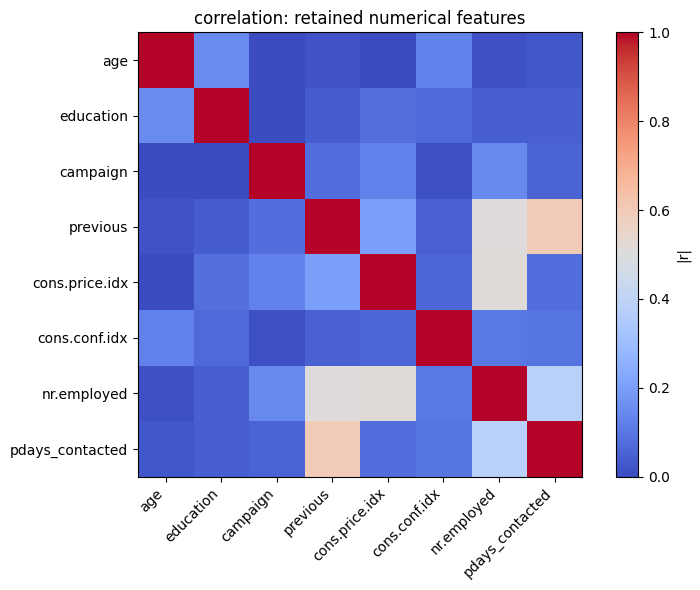

In [8]:
VAR_THRESHOLD = 0.01
CORR_THRESHOLD = 0.85

# variance filter (computed on training set only)
variances = X_train.var()
low_var_cols = variances[variances < VAR_THRESHOLD].index.tolist()
print(f"low variance cols (var < {VAR_THRESHOLD}): {low_var_cols}")

# correlation filter on continuous/ordinal cols only
num_cols_current = ["age", "education", "campaign", "pdays", "previous",
                    "emp.var.rate", "cons.price.idx", "cons.conf.idx",
                    "euribor3m", "nr.employed", "pdays_contacted"]
corr_matrix = X_train[num_cols_current].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# collect cols to drop: for each correlated pair, drop the one with higher avg correlation
corr_drop_cols = set()
for col in upper.columns:
    for row in upper.index:
        if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > CORR_THRESHOLD:
            # compare mean correlation of each to rest of features
            mean_col = corr_matrix[col].mean()
            mean_row = corr_matrix[row].mean()
            drop = col if mean_col > mean_row else row
            corr_drop_cols.add(drop)
            print(f"  correlated: {row} vs {col} (r={upper.loc[row, col]:.3f}) -> drop '{drop}'")

# conceptual removal
CONCEPTUAL_DROP = ["pdays"]
print(f"\nconceptual drop: {CONCEPTUAL_DROP} (96.2% sentinel-imputed; pdays_contacted retains the signal)")

# combine all cols to drop
ALL_DROP = list(set(low_var_cols) | corr_drop_cols | set(CONCEPTUAL_DROP))
print(f"\nall cols dropped: {sorted(ALL_DROP)}")

# apply to all splits
X_train = X_train.drop(columns=ALL_DROP)
X_val   = X_val.drop(columns=ALL_DROP)
X_test  = X_test.drop(columns=ALL_DROP)

print(f"\nfinal shape - train: {X_train.shape}, val: {X_val.shape}, test: {X_test.shape}")
print(f"remaining features ({X_train.shape[1]}):\n{X_train.columns.tolist()}")

# visualise correlation heatmap of retained numeric cols
retained_num = [c for c in num_cols_current if c not in ALL_DROP]
fig, ax = plt.subplots(figsize=(8, 6))
corr_retained = X_train[retained_num].corr()
im = ax.imshow(corr_retained.abs(), vmin=0, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(retained_num))); ax.set_xticklabels(retained_num, rotation=45, ha="right")
ax.set_yticks(range(len(retained_num))); ax.set_yticklabels(retained_num)
plt.colorbar(im, ax=ax, label="|r|")
ax.set_title("correlation: retained numerical features")
plt.tight_layout()
plt.show()

## Task 9: Addressing Class Imbalance

### Class Distribution in the Training Set

The training set has 28,831 rows. Preserving the stratified split, 25,583 rows are labelled `"no"` (88.7%) and 3,248 are labelled `"yes"` (11.3%), an imbalance ratio of 7.88:1.

### Why Imbalance Is a Concern Here

The minority class (`"yes"`) is the important outcome because the bank runs this campaign specifically to identify clients likely to subscribe. Failing to detect a true subscriber (false negative) is a direct business cost. The majority class (`"no"`) is of less value. This asymmetry means the cost of a false negative outweighs the cost of a false positive, making recall on the positive class the most relevant metric.

Logistic Regression minimises cross-entropy loss, which is dominated by the majority class when imbalance is severe. The decision boundary drifts toward classifying nearly all records as `"no"` because that path already achieves low loss most of the time. The model effectively treats the minority class as noise. SMOTE counters this by increasing the density of minority examples in the training set, forcing the loss surface to assign more weight to correctly classifying the positive class.

### SMOTE: Assumptions and Expected Effect on the Learning Algorithm

SMOTE (Synthetic Minority Over-sampling Technique) generates synthetic minority samples rather than duplicating existing ones. For each minority observation, it selects $k$ nearest neighbors in the feature space and creates new points by linear interpolation along the segments connecting the observation to its neighbors:

$$x_{\text{new}} = x_i + \lambda \cdot (x_{nn} - x_i), \quad \lambda \in [0, 1]$$

The assumption is that the minority class occupies a locally smooth manifold in feature space, and that any point on a line segment between two nearby minority examples is also a plausible minority example. This is a geometric assumption: it assumes numeric features carry meaningful inter-sample distances and that interpolated points represent realistic observations. After all encoding and scaling steps, this assumption is reasonably satisfied for the continuous and ordinal features. For OHE binary features, interpolation produces fractional values (e.g. 0.3 for a binary column), which violates the intended {0, 1} interpretation. This is a known limitation of SMOTE applied to mixed-type feature spaces.

The practical effects on Logistic Regression are as follows. First, the loss landscape shifts: with 1:1 class balance after SMOTE, the positive class contributes roughly as many gradient updates as the negative class, so the decision boundary moves toward a region where the positive class has real density rather than toward the dominant negative region. Second, the synthetic points add regularity to the minority class boundary, effectively smoothing the region where the model must separate classes. This tends to improve recall at some cost to precision, which is probably the right tradeoff for a campaign identification task.

SMOTE must be applied after all transformations are fitted (imputation, encoding, scaling) so that synthetic points are generated in the fully preprocessed feature space where distances are meaningful. Generating synthetic samples on raw, unscaled, or unencoded data would produce points in the wrong space.

### Implications if Resampling Were Applied Before Splitting

If SMOTE were applied to the full dataset before splitting, synthetic minority samples would be distributed across all three partitions. Some synthetically generated rows would appear in the validation and test sets. These rows are not real observations as they are interpolated points based on training examples. The model would then be evaluated against synthetic data it was implicitly trained near, inflating recall and F1 on the minority class.

### How Imbalance Affects Accuracy, Precision, and Recall

**Accuracy** is misleading under imbalance. A model that predicts `"no"` for every record achieves 88.7% accuracy without learning anything useful. Accuracy treats every false negative and false positive as equally costly, which does not match the business objective.

**Precision** for the positive class measures the fraction of predicted subscribers who actually subscribe: $\text{Precision} = \frac{TP}{TP + FP}$. Under imbalance, a conservative model rarely predicts `"yes"`, so when it does predict positive, it tends to be correct. Precision can appear artificially high while the model still misses most actual subscribers.

**Recall** for the positive class measures the fraction of actual subscribers who are correctly identified: $\text{Recall} = \frac{TP}{TP + FN}$. Under imbalance, recall on the positive class collapses because the model predicts `"yes"` so rarely. This is the metric most directly harmed by class imbalance and the one that matters most for the campaign use case.

F1 score ($\frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$) and AUC-ROC are more informative than accuracy here because both account for the model's ability to distinguish minority examples rather than just predicting the majority class.

In [9]:
# encode target to numeric (no=0, yes=1) for all splits
label_map = {"no": 0, "yes": 1}
y_train_enc = y_train.map(label_map)
y_val_enc   = y_val.map(label_map)
y_test_enc  = y_test.map(label_map)

# class distribution before resampling
pre_counts = y_train_enc.value_counts().sort_index()
print("class dist before SMOTE (train):")
print(f"  0 (no) : {pre_counts[0]}  ({pre_counts[0]/len(y_train_enc)*100:.1f}%)")
print(f"  1 (yes): {pre_counts[1]}  ({pre_counts[1]/len(y_train_enc)*100:.1f}%)")
print(f"  imbalance ratio: {pre_counts[0]/pre_counts[1]:.2f}:1")

# apply SMOTE to training set only (after all transformations)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train_enc)

# class distribution after resampling
post_counts = np.bincount(y_train_res)
print(f"\nclass dist after SMOTE (train):")
print(f"  0 (no) : {post_counts[0]}  ({post_counts[0]/len(y_train_res)*100:.1f}%)")
print(f"  1 (yes): {post_counts[1]}  ({post_counts[1]/len(y_train_res)*100:.1f}%)")
print(f"  total training rows: {len(y_train_res)} (was {len(y_train_enc)})")

# val and test remain unchanged
print(f"\nval/test unchanged:")
print(f"  val  - 0: {(y_val_enc==0).sum()}, 1: {(y_val_enc==1).sum()}")
print(f"  test - 0: {(y_test_enc==0).sum()}, 1: {(y_test_enc==1).sum()}")
print(f"\nX_train_res shape: {X_train_res.shape}")

class dist before SMOTE (train):
  0 (no) : 25583  (88.7%)
  1 (yes): 3248  (11.3%)
  imbalance ratio: 7.88:1

class dist after SMOTE (train):
  0 (no) : 25583  (50.0%)
  1 (yes): 25583  (50.0%)
  total training rows: 51166 (was 28831)

val/test unchanged:
  val  - 0: 5482, 1: 696
  test - 0: 5483, 1: 696

X_train_res shape: (51166, 38)


## Task 10: Training a Logistic Regression Model

### Training Set vs Evaluation Set

The model is trained on `X_train_res` and `y_train_res`, the SMOTE-augmented training data. Evaluation is done on the original, untouched validation set. SMOTE only balances the training distribution to improve learning. The validation set must preserve the real class proportions (88.7% / 11.3%) because that is what the model will encounter in deployment. Evaluating on a synthetically balanced validation set would give misleading recall and F1 figures that do not reflect actual operating conditions.

### Zero Rule Baseline

The zero rule baseline always predicts the majority class (`"no"`) regardless of input. On the validation set it achieves 88.7% accuracy. This is the ceiling for a model that ignores the minority class entirely. A model that scores below this baseline but detects real subscribers is more useful than one that scores above it by predicting only `"no"`.

Accuracy is therefore not the right optimisation target here. A model with 88.7% accuracy that predicts `"yes"` for zero clients generates no campaign leads at all. Precision and recall on the positive class should be the indicators instead.

### Interpreting the Results

The model accuracy is 0.8177, below the zero-rule baseline of 0.8873. This is expected and desirable. SMOTE shifted the decision boundary to predict `"yes"` more often, which necessarily reduces accuracy on a majority-skewed validation set. The gain is reflected in recall: the model correctly identifies 64.1% of actual subscribers (446 out of 696), versus 0% for the zero-rule baseline.

The precision-recall tradeoff is 0.34 / 0.64. Precision is low because the model generates a sizeable number of false positives (876 majority-class records predicted as `"yes"`). For a marketing campaign, this is an acceptable cost since contacting a non-subscriber wastes one phone call, while missing a subscriber forfeits the subscription entirely.

In [10]:
# train on smote-balanced training set
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_res, y_train_res)

# predict on original (unmodified) validation set
y_pred = clf.predict(X_val)

# metrics
acc          = accuracy_score(y_val_enc, y_pred)
prec         = precision_score(y_val_enc, y_pred, zero_division=0)
rec          = recall_score(y_val_enc, y_pred, zero_division=0)
baseline_acc = (y_val_enc == 0).mean()

print(f"zero-rule baseline acc : {baseline_acc:.4f}")
print(f"model accuracy         : {acc:.4f}  (delta: {acc - baseline_acc:+.4f})")
print(f"precision (class 1)    : {prec:.4f}")
print(f"recall    (class 1)    : {rec:.4f}")
print(f"\nclassification report:")
print(classification_report(y_val_enc, y_pred, target_names=["no", "yes"], digits=4))

# confusion matrix
tn, fp, fn, tp = confusion_matrix(y_val_enc, y_pred).ravel()
print("confusion matrix (validation set):")
print(f"                predicted no    predicted yes")
print(f"actual no       TN = {tn:<10}  FP = {fp}")
print(f"actual yes      FN = {fn:<10}  TP = {tp}")

zero-rule baseline acc : 0.8873
model accuracy         : 0.8177  (delta: -0.0696)
precision (class 1)    : 0.3374
recall    (class 1)    : 0.6408

classification report:
              precision    recall  f1-score   support

          no     0.9485    0.8402    0.8911      5482
         yes     0.3374    0.6408    0.4420       696

    accuracy                         0.8177      6178
   macro avg     0.6429    0.7405    0.6666      6178
weighted avg     0.8797    0.8177    0.8405      6178

confusion matrix (validation set):
                predicted no    predicted yes
actual no       TN = 4606        FP = 876
actual yes      FN = 250         TP = 446


## Final (Critical) Discussion

### Design Choices and Rejected Alternatives

**Imputation.** Mode imputation was chosen for five low-missingness categorical columns because it is the simplest strategy that does not introduce new category levels. An alternative was k-nearest-neighbor imputation, but KNN on raw categorical features requires a distance metric over strings, which is undefined without first encoding the categories. Since encoding must come after imputation in a leakage-free pipeline, KNN imputation was not viable at this stage.

**Encoding.** Ordinal encoding was used only for `education` because it has a clear rank ordering with roughly uniform gaps. All other categoricals were one-hot encoded with `drop="first"` to avoid the dummy variable trap. An alternative was target encoding, which replaces each category with the mean of the target for that level. This was rejected because target encoding on small categories (e.g. `job=student`, `month=dec`) produces noisy estimates that overfit, and it requires careful regularisation to avoid leaking target information into the features.

**Feature selection.** Variance and correlation filters were used because they are model-agnostic and interpretable. Recursive Feature Elimination (RFE) was considered but rejected as RFE wraps around the model itself and would require repeated refitting of Logistic Regression during selection, blurring the line between preprocessing and training.

**Resampling.** SMOTE was chosen over random oversampling because duplicating minority rows risks overfitting to the exact minority points, while SMOTE generates interpolated examples that smooth the minority class boundary. Random undersampling was rejected because discarding roughly 22,000 majority rows would waste most of the dataset and reduce the model's ability to learn the majority class boundary accurately.